In [17]:

import os
import re 
import json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image, ImageDraw

pd.set_option("display.max_colwidth", 120)




In [2]:
wind  = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")
hydro = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/hydro_reservoir_CN-asRoW_US-asQC_staticLCI_threeGWP100.xlsx")
pv    = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/PV_CN_US_staticLCI_threeGWP100.xlsx")

## tables just like B.1 

In [3]:
def add_diff_columns(df):
    df = df.copy()

    df["diff% pGWP_fixedCO2"] = (
        (df["pGWP100_fixedCO2"] - df["gwp100"]) / df["gwp100"] * 100
    ).round(0).astype(int)

    df["diff% pGWP_dpCO2"] = (
        (df["pGWP100_dpCO2"] - df["gwp100"]) / df["gwp100"] * 100
    ).round(0).astype(int)

    return df


In [4]:
hydro = add_diff_columns(hydro)
wind  = add_diff_columns(wind)
pv    = add_diff_columns(pv)

In [5]:
def highlight_threshold(val):
    if pd.isna(val):
        return ""
    if abs(val) >= 10:
        return "background-color: #ff6b6b; color: black;"   # red
    elif abs(val) >= 5:
        return "background-color: #f4b084; color: black;"   # yellow
    else:
        return ""



In [6]:

hydro.style.applymap(
        highlight_threshold,
        subset=["diff% pGWP_fixedCO2", "diff% pGWP_dpCO2"]
    ).set_properties(
        subset=["Activity"],
        **{"white-space": "nowrap"}
    )


/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_932/4053345779.py:1: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  hydro.style.applymap(


,Activity,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2,diff% pGWP_fixedCO2,diff% pGWP_dpCO2
0,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2030",0.027212,0.030422,0.026565,12,-2
1,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2050",0.025149,0.028633,0.025134,14,0
2,"market for electricity, hydro, high voltage, US, SSP2-M, 2030",0.027237,0.029438,0.026299,8,-3
3,"market for electricity, hydro, high voltage, US, SSP2-M, 2050",0.026952,0.026994,0.027105,0,1
4,"market for electricity, hydro, high voltage, US, SSP5-H, 2030",0.027293,0.028536,0.025919,5,-5
5,"market for electricity, hydro, high voltage, US, SSP5-H, 2050",0.027074,0.024032,0.026579,-11,-2
6,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2030",0.050523,0.057266,0.050021,13,-1
7,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2050",0.047437,0.053979,0.047402,14,0
8,"market for electricity, hydro, high voltage, CN, SSP2-M, 2030",0.050624,0.055848,0.049911,10,-1
9,"market for electricity, hydro, high voltage, CN, SSP2-M, 2050",0.049844,0.049701,0.049930,0,0


In [7]:
# wind and PV has 2040 rows, and we don't use them 
wind = wind[wind["Activity"].str.contains(r"\b(2030|2050)\b", regex=True)]

wind.style.applymap(
        highlight_threshold,
        subset=["diff% pGWP_fixedCO2", "diff% pGWP_dpCO2"]
    ).set_properties(
        subset=["Activity"],
        **{"white-space": "nowrap"}
    )


/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_932/915099166.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  wind = wind[wind["Activity"].str.contains(r"\b(2030|2050)\b", regex=True)]
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_932/915099166.py:4: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  wind.style.applymap(


,Activity,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2,diff% pGWP_fixedCO2,diff% pGWP_dpCO2
0,"market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2030",0.036905,0.041520,0.036365,13,-1
2,"market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2050",0.017832,0.019952,0.017591,12,-1
3,"market for electricity, wind, high voltage, CN-NM, SSP2-M, 2030",0.037723,0.041415,0.037095,10,-2
5,"market for electricity, wind, high voltage, CN-NM, SSP2-M, 2050",0.031185,0.030810,0.030951,-1,-1
6,"market for electricity, wind, high voltage, CN-NM, SSP5-H, 2030",0.038734,0.041703,0.037964,8,-2
8,"market for electricity, wind, high voltage, CN-NM, SSP5-H, 2050",0.034395,0.030785,0.033988,-10,-1
9,"market for electricity, wind, high voltage, US-TRE, SSP1-VLLO, 2030",0.020637,0.023218,0.020336,13,-1
11,"market for electricity, wind, high voltage, US-TRE, SSP1-VLLO, 2050",0.009972,0.011157,0.009837,12,-1
12,"market for electricity, wind, high voltage, US-TRE, SSP2-M, 2030",0.021095,0.023160,0.020744,10,-2
14,"market for electricity, wind, high voltage, US-TRE, SSP2-M, 2050",0.017439,0.017229,0.017308,-1,-1


In [8]:
pv = pv[pv["Activity"].str.contains(r"\b(2030|2050)\b", regex=True)]

pv.style.applymap(
        highlight_threshold,
        subset=["diff% pGWP_fixedCO2", "diff% pGWP_dpCO2"]
    ).set_properties(
        subset=["Activity"],
        **{"white-space": "nowrap"}
    )


/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_932/3604744248.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pv = pv[pv["Activity"].str.contains(r"\b(2030|2050)\b", regex=True)]
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_932/3604744248.py:3: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  pv.style.applymap(


,Activity,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2,diff% pGWP_fixedCO2,diff% pGWP_dpCO2
0,"market for electricity, PV, low voltage, CN, SSP1-VLLO, 2030",0.032003,0.035375,0.030962,11,-3
2,"market for electricity, PV, low voltage, CN, SSP1-VLLO, 2050",0.010065,0.010716,0.009459,6,-6
3,"market for electricity, PV, low voltage, CN, SSP2-M, 2030",0.032911,0.035515,0.031793,8,-3
5,"market for electricity, PV, low voltage, CN, SSP2-M, 2050",0.020241,0.019521,0.019611,-4,-3
6,"market for electricity, PV, low voltage, CN, SSP5-H, 2030",0.034533,0.036574,0.033279,6,-4
8,"market for electricity, PV, low voltage, CN, SSP5-H, 2050",0.024782,0.021741,0.024011,-12,-3
9,"market for electricity, PV, low voltage, US, SSP1-VLLO, 2030",0.020103,0.022236,0.019463,11,-3
11,"market for electricity, PV, low voltage, US, SSP1-VLLO, 2050",0.006560,0.007007,0.006184,7,-6
12,"market for electricity, PV, low voltage, US, SSP2-M, 2030",0.020738,0.022395,0.020048,8,-3
14,"market for electricity, PV, low voltage, US, SSP2-M, 2050",0.013044,0.012596,0.012654,-3,-3


## plots 

In [9]:
all_df = pd.concat([hydro, wind, pv], ignore_index=True)
all_df.columns = [str(c).strip() for c in all_df.columns]

diff_fixed_col = next(c for c in all_df.columns if "diff% pGWP_fixedCO2" in c)
diff_dp_col    = next(c for c in all_df.columns if "diff% pGWP_dpCO2" in c)

In [10]:
all_df

,Activity,gwp100,pGWP100_fixedCO2,pGWP100_dpCO2,diff% pGWP_fixedCO2,diff% pGWP_dpCO2
0,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2030",0.027212,0.030422,0.026565,12,-2
1,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2050",0.025149,0.028633,0.025134,14,0
2,"market for electricity, hydro, high voltage, US, SSP2-M, 2030",0.027237,0.029438,0.026299,8,-3
3,"market for electricity, hydro, high voltage, US, SSP2-M, 2050",0.026952,0.026994,0.027105,0,1
4,"market for electricity, hydro, high voltage, US, SSP5-H, 2030",0.027293,0.028536,0.025919,5,-5
5,"market for electricity, hydro, high voltage, US, SSP5-H, 2050",0.027074,0.024032,0.026579,-11,-2
6,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2030",0.050523,0.057266,0.050021,13,-1
7,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2050",0.047437,0.053979,0.047402,14,0
8,"market for electricity, hydro, high voltage, CN, SSP2-M, 2030",0.050624,0.055848,0.049911,10,-1
9,"market for electricity, hydro, high voltage, CN, SSP2-M, 2050",0.049844,0.049701,0.049930,0,0


In [11]:
def infer_region(s):
    s = str(s)
    if ", US," in s or ", US " in s or re.search(r"\bUS\b", s):
        return "US"
    if ", CN," in s or ", CN " in s or re.search(r"\bCN\b", s):
        return "CN"
    return None

def infer_scenario(s):
    s = str(s)
    if "SSP1-VLLO" in s: return "SSP1-VLLO"
    if "SSP5-H" in s:    return "SSP5-H"
    if "SSP2-M" in s:    return "SSP2-M"
    return None

def infer_year(s):
    m = re.search(r",\s*(20\d{2})\s*$", str(s))
    return int(m.group(1)) if m else None

def infer_tech(s):
    s = str(s).lower()
    if "hydro" in s: return "hydro"
    if "wind" in s:  return "wind"
    if "solar" in s or " pv" in s or "pv," in s: return "pv"
    return None

tidy = pd.DataFrame({
    "Activity": all_df["Activity"],
    "region": all_df["Activity"].map(infer_region),
    "scenario": all_df["Activity"].map(infer_scenario),
    "year": all_df["Activity"].map(infer_year),
    "tech": all_df["Activity"].map(infer_tech),
    "diff_fixed": pd.to_numeric(all_df[diff_fixed_col], errors="coerce"),
    "diff_dp": pd.to_numeric(all_df[diff_dp_col], errors="coerce"),
})

df2050 = tidy[
    (tidy["year"] == 2050) &
    (tidy["scenario"].isin(["SSP1-VLLO", "SSP5-H"])) &
    (tidy["tech"].isin(["hydro", "wind", "pv"])) &
    (tidy["region"].isin(["US", "CN"]))
].drop_duplicates(subset=["tech","region","scenario"]).copy()


df2050

,Activity,region,scenario,year,tech,diff_fixed,diff_dp
1,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2050",US,SSP1-VLLO,2050,hydro,14,0
5,"market for electricity, hydro, high voltage, US, SSP5-H, 2050",US,SSP5-H,2050,hydro,-11,-2
7,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2050",CN,SSP1-VLLO,2050,hydro,14,0
11,"market for electricity, hydro, high voltage, CN, SSP5-H, 2050",CN,SSP5-H,2050,hydro,-10,-1
13,"market for electricity, wind, high voltage, CN-NM, SSP1-VLLO, 2050",CN,SSP1-VLLO,2050,wind,12,-1
17,"market for electricity, wind, high voltage, CN-NM, SSP5-H, 2050",CN,SSP5-H,2050,wind,-10,-1
19,"market for electricity, wind, high voltage, US-TRE, SSP1-VLLO, 2050",US,SSP1-VLLO,2050,wind,12,-1
23,"market for electricity, wind, high voltage, US-TRE, SSP5-H, 2050",US,SSP5-H,2050,wind,-10,-1
25,"market for electricity, PV, low voltage, CN, SSP1-VLLO, 2050",CN,SSP1-VLLO,2050,pv,6,-6
29,"market for electricity, PV, low voltage, CN, SSP5-H, 2050",CN,SSP5-H,2050,pv,-12,-3


### only 2050 plot 

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image, ImageDraw

def plot_fixedCO2_dumbbell_2050(df2050, figsize=(8, 4)):
    """
    Final plot (single figure):
    - Only fixedCO2 (diff_fixed)
    - SSP1-VLLO (filled circle) vs SSP5-H (hollow circle) connected by a vertical line
    - Tech on x: hydro / wind / pv
    - Region separated within each tech: US left, CN right
    - CN/US shown as small flag icons near the mid-point of each dumbbell
    - Black dashed 0% reference line (IPCC baseline)
    Requires df2050 columns: ['tech','region','scenario','diff_fixed']
    """

    # --- small flag images (no emoji font issues) ---
    def make_flag_US(w=120, h=80):
        img = Image.new("RGBA", (w, h), (255, 255, 255, 0))
        d = ImageDraw.Draw(img)
        stripe_h = h / 13
        red, white = (178, 34, 52, 255), (255, 255, 255, 255)
        for i in range(13):
            y0, y1 = int(i * stripe_h), int((i + 1) * stripe_h)
            d.rectangle([0, y0, w, y1], fill=red if i % 2 == 0 else white)
        blue = (60, 59, 110, 255)
        cw, ch = int(w * 0.4), int(h * 0.54)
        d.rectangle([0, 0, cw, ch], fill=blue)
        for r in range(5):
            for c in range(6):
                x = int((c + 1) * cw / 7)
                y = int((r + 1) * ch / 6)
                d.ellipse([x - 2, y - 2, x + 2, y + 2], fill=(255, 255, 255, 255))
        return np.asarray(img)

    def make_flag_CN(w=120, h=80):
        img = Image.new("RGBA", (w, h), (255, 255, 255, 0))
        d = ImageDraw.Draw(img)
        red, yellow = (222, 41, 16, 255), (255, 222, 0, 255)
        d.rectangle([0, 0, w, h], fill=red)
        cx, cy = int(w * 0.18), int(h * 0.25)
        r1, r2 = 14, 6
        pts = []
        for k in range(10):
            ang = (np.pi / 2) + k * np.pi / 5
            r = r1 if k % 2 == 0 else r2
            pts.append((cx + int(r * np.cos(ang)), cy - int(r * np.sin(ang))))
        d.polygon(pts, fill=yellow)
        for (sx, sy) in [(int(w * 0.32), int(h * 0.12)), (int(w * 0.38), int(h * 0.22)),
                         (int(w * 0.38), int(h * 0.36)), (int(w * 0.32), int(h * 0.46))]:
            d.ellipse([sx - 4, sy - 4, sx + 4, sy + 4], fill=yellow)
        return np.asarray(img)

    flag_img = {"US": make_flag_US(), "CN": make_flag_CN()}

    def add_flag(ax, x, y, img_arr, zoom=0.18, alpha=0.95, zorder=1):
        im = OffsetImage(img_arr, zoom=zoom)
        ab = AnnotationBbox(im, (x, y), frameon=False, box_alignment=(0.5, 0.5), zorder=zorder)
        ab.set_alpha(alpha)
        ax.add_artist(ab)

    # --- layout / styling ---
    tech_order = ["hydro", "wind", "pv"]
    region_order = ["US", "CN"]
    scenario_1 = "SSP1-VLLO"
    scenario_5 = "SSP5-H"

    x_base = {t: i for i, t in enumerate(tech_order)}
    dx_region = {"US": -0.07, "CN": +0.07}

    color_fixed = "#3B2E83"
    marker = "o"

    # y-limits from fixed only
    ymax = float(np.nanmax(np.abs(df2050["diff_fixed"].values)))
    ymax = max(5, float(np.ceil(ymax / 5) * 5))

    fig, ax = plt.subplots(figsize=figsize)

    # baseline (IPCC)
    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    # separators
    for i in range(len(tech_order) - 1):
        ax.axvline(i + 0.5, linewidth=1.6, color="0.65", alpha=0.9)

    # dumbbells
    for tech in tech_order:
        for region in region_order:
            x0 = x_base[tech] + dx_region[region]

            r1 = df2050[(df2050["tech"] == tech) & (df2050["region"] == region) & (df2050["scenario"] == scenario_1)]
            r5 = df2050[(df2050["tech"] == tech) & (df2050["region"] == region) & (df2050["scenario"] == scenario_5)]
            if r1.empty or r5.empty:
                continue

            y1 = float(r1.iloc[0]["diff_fixed"])
            y5 = float(r5.iloc[0]["diff_fixed"])

            # connector
            ax.plot([x0, x0], [y1, y5], linewidth=1.4, alpha=0.85, zorder=2, color=color_fixed)

            # centered flag with tiny anti-overlap jitter
            y_flag = 0.5 * (y1 + y5) + (0.5 if region == "CN" else -0.5)
            add_flag(ax, x0, y_flag, flag_img[region], zoom=0.18, alpha=0.95, zorder=1)

            # points
            ax.scatter(x0, y1, s=60, marker=marker, edgecolor=color_fixed, facecolor=color_fixed,
                       linewidth=1.5, zorder=3)
            ax.scatter(x0, y5, s=60, marker=marker, edgecolor=color_fixed, facecolor="none",
                       linewidth=1.5, zorder=3)

    # axes
    ax.set_xticks([x_base[t] for t in tech_order])
    ax.set_xticklabels(["Hydro", "Wind", "Solar PV"])
    ax.set_ylabel("Change to IPCC GWP100 reference (%)")
    ax.set_ylim(-ymax, ymax)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v:g}%"))

    # legend
    h1 = mlines.Line2D([], [], color=color_fixed, marker=marker, linestyle="None",
                       markersize=7, markerfacecolor=color_fixed, markeredgewidth=1.5,
                       label="pGWP100[fixedCO$_2$], SSP1-19/2050")
    h5 = mlines.Line2D([], [], color=color_fixed, marker=marker, linestyle="None",
                       markersize=7, markerfacecolor="none", markeredgewidth=1.5,
                       label="pGWP100[fixedCO$_2$], SSP5-85/2050")

    leg = ax.legend(handles=[h1, h5], loc="upper right",
                    frameon=True, fancybox=True, shadow=False, framealpha=1.0)
    leg.get_frame().set_facecolor((1, 1, 1, 0.15))  # transparent white
    leg.get_frame().set_edgecolor("0.6")

    fig.tight_layout()
    return fig, ax

(<Figure size 800x400 with 1 Axes>,
 <Axes: ylabel='Change to IPCC GWP100 reference (%)'>)

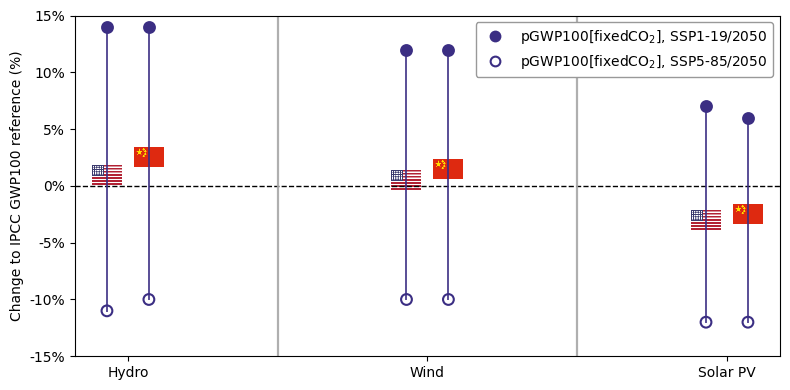

In [19]:
plot_fixedCO2_dumbbell_2050(df2050)

## adding 2030 

In [22]:
df203050 = (
    tidy[
        (tidy["year"].isin([2030, 2050])) &
        (tidy["scenario"].isin(["SSP1-VLLO", "SSP5-H"])) &
        (tidy["tech"].isin(["hydro", "wind", "pv"])) &
        (tidy["region"].isin(["US", "CN"]))
    ]
    .drop_duplicates(subset=["year", "tech", "region", "scenario"])
    .copy()
)

df203050.sort_values(["tech","region","year","scenario"], inplace=True)
df203050

,Activity,region,scenario,year,tech,diff_fixed,diff_dp
6,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2030",CN,SSP1-VLLO,2030,hydro,13,-1
10,"market for electricity, hydro, high voltage, CN, SSP5-H, 2030",CN,SSP5-H,2030,hydro,8,-2
7,"market for electricity, hydro, high voltage, CN, SSP1-VLLO, 2050",CN,SSP1-VLLO,2050,hydro,14,0
11,"market for electricity, hydro, high voltage, CN, SSP5-H, 2050",CN,SSP5-H,2050,hydro,-10,-1
0,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2030",US,SSP1-VLLO,2030,hydro,12,-2
4,"market for electricity, hydro, high voltage, US, SSP5-H, 2030",US,SSP5-H,2030,hydro,5,-5
1,"market for electricity, hydro, high voltage, US, SSP1-VLLO, 2050",US,SSP1-VLLO,2050,hydro,14,0
5,"market for electricity, hydro, high voltage, US, SSP5-H, 2050",US,SSP5-H,2050,hydro,-11,-2
24,"market for electricity, PV, low voltage, CN, SSP1-VLLO, 2030",CN,SSP1-VLLO,2030,pv,11,-3
28,"market for electricity, PV, low voltage, CN, SSP5-H, 2030",CN,SSP5-H,2030,pv,6,-4


In [39]:
def plot_fixedCO2_dumbbell_2030_2050_oneflag(df, figsize=(8.5, 4.6)):
    """
    FixedCO2 only, years 2030 & 2050:
      - Year encodes marker: 2030=triangle, 2050=circle
      - Scenario encodes fill: SSP1 filled, SSP5 hollow
      - Connector per (tech, region, year) connects SSP1 vs SSP5
      - ONE flag per (tech, region) shared for both years (so 2 flags per technology)
    Required columns: ['tech','region','scenario','year','diff_fixed']
    """
    # --- flags ---
    def make_flag_US(w=120, h=80):
        img = Image.new("RGBA",(w,h),(255,255,255,0)); d=ImageDraw.Draw(img)
        stripe_h=h/13; red=(178,34,52,255); white=(255,255,255,255)
        for i in range(13):
            y0=int(i*stripe_h); y1=int((i+1)*stripe_h)
            d.rectangle([0,y0,w,y1], fill=red if i%2==0 else white)
        blue=(60,59,110,255); cw=int(w*0.4); ch=int(h*0.54)
        d.rectangle([0,0,cw,ch], fill=blue)
        for r in range(5):
            for c in range(6):
                x=int((c+1)*cw/7); y=int((r+1)*ch/6)
                d.ellipse([x-2,y-2,x+2,y+2], fill=(255,255,255,255))
        return np.asarray(img)

    def make_flag_CN(w=120, h=80):
        img = Image.new("RGBA",(w,h),(255,255,255,0)); d=ImageDraw.Draw(img)
        red=(222,41,16,255); yellow=(255,222,0,255)
        d.rectangle([0,0,w,h], fill=red)
        cx,cy=int(w*0.18),int(h*0.25); r1,r2=14,6
        pts=[]
        for k in range(10):
            ang=(np.pi/2)+k*np.pi/5; r=r1 if k%2==0 else r2
            pts.append((cx+int(r*np.cos(ang)), cy-int(r*np.sin(ang))))
        d.polygon(pts, fill=yellow)
        for (sx,sy) in [(int(w*0.32), int(h*0.12)), (int(w*0.38), int(h*0.22)),
                        (int(w*0.38), int(h*0.36)), (int(w*0.32), int(h*0.46))]:
            d.ellipse([sx-4,sy-4,sx+4,sy+4], fill=yellow)
        return np.asarray(img)

    flag_img={"US":make_flag_US(),"CN":make_flag_CN()}

    def add_flag(ax,x,y,img_arr,zoom=0.18,alpha=0.95,zorder=1):
        im=OffsetImage(img_arr, zoom=zoom)
        ab=AnnotationBbox(im,(x,y), frameon=False, box_alignment=(0.5,0.5), zorder=zorder)
        ab.set_alpha(alpha); ax.add_artist(ab)

    tech_order=["hydro","wind","pv"]
    region_order=["US","CN"]
    year_order=[2030,2050]
    scenario_1="SSP1-VLLO"
    scenario_5="SSP5-H"

    x_base={t:i for i,t in enumerate(tech_order)}
    dx_region={"US":-0.09,"CN":+0.09}
    dx_year={2030:-0.03, 2050:+0.03}

    marker_by_year={2030:"^", 2050:"o"}
    color="#3B2E83"

    ymax=float(np.nanmax(np.abs(df["diff_fixed"].values)))
    ymax=max(5, float(np.ceil(ymax/5)*5))

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    for i in range(len(tech_order)-1):
        ax.axvline(i+0.5, linewidth=1.6, color="0.65", alpha=0.9)

    # Plot dumbbells
    for tech in tech_order:
        for region in region_order:
            for year in year_order:
                x0 = x_base[tech] + dx_region[region] + dx_year[year]

                r1 = df[(df["tech"]==tech)&(df["region"]==region)&(df["year"]==year)&(df["scenario"]==scenario_1)]
                r5 = df[(df["tech"]==tech)&(df["region"]==region)&(df["year"]==year)&(df["scenario"]==scenario_5)]
                if r1.empty or r5.empty:
                    continue

                y1=float(r1.iloc[0]["diff_fixed"])
                y5=float(r5.iloc[0]["diff_fixed"])

                ax.plot([x0,x0],[y1,y5], linewidth=1.3, alpha=0.85, zorder=2, color=color)

                mk = marker_by_year[year]
                ax.scatter(x0, y1, s=60, marker=mk, edgecolor=color, facecolor=color,
                           linewidth=1.5, zorder=3)
                ax.scatter(x0, y5, s=60, marker=mk, edgecolor=color, facecolor="none",
                           linewidth=1.5, zorder=3)

            # ONE shared flag for this tech+region (after both years plotted)
            # Place near 2030 x, shifted right, and at mean of year midpoints
            x_flag = x_base[tech] + dx_region[region] + dx_year[2030] + 0.05

            mids=[]
            for yr in year_order:
                r1 = df[(df["tech"]==tech)&(df["region"]==region)&(df["year"]==yr)&(df["scenario"]==scenario_1)]
                r5 = df[(df["tech"]==tech)&(df["region"]==region)&(df["year"]==yr)&(df["scenario"]==scenario_5)]
                if not r1.empty and not r5.empty:
                    mids.append(0.5*(float(r1.iloc[0]["diff_fixed"]) + float(r5.iloc[0]["diff_fixed"])))
            if mids:
                y_flag=float(np.mean(mids))
                y_flag += (0.25 if region=="CN" else -0.25)  # small anti-overlap CN vs US
                add_flag(ax, x_flag, y_flag, flag_img[region], zoom=0.17, alpha=0.95, zorder=1)

    ax.set_xticks([x_base[t] for t in tech_order])
    ax.set_xticklabels(["Hydro","Wind","Solar PV"])
    ax.set_ylabel("pGWP100[fixedCO$_2$],\nchange (%) to IPCC GWP100 reference (the central 0% line)")
    ax.set_ylim(-ymax, ymax)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,p: f"{v:g}%"))

    # Legend
    h_2050_filled = mlines.Line2D([], [], color=color, marker="o", linestyle="None",
                                 markersize=7, markerfacecolor=color, markeredgewidth=1.5,
                                 label="2050, SSP1-19")
    h_2050_open   = mlines.Line2D([], [], color=color, marker="o", linestyle="None",
                                 markersize=7, markerfacecolor="none", markeredgewidth=1.5,
                                 label="2050, SSP5-85")
    h_2030_filled = mlines.Line2D([], [], color=color, marker="^", linestyle="None",
                                 markersize=7, markerfacecolor=color, markeredgewidth=1.5,
                                 label="2030, SSP1-19")
    h_2030_open   = mlines.Line2D([], [], color=color, marker="^", linestyle="None",
                                 markersize=7, markerfacecolor="none", markeredgewidth=1.5,
                                 label="2030, SSP5-85")

    leg=ax.legend(handles=[h_2050_filled, h_2050_open, h_2030_filled, h_2030_open],
                  loc="lower center", frameon=True, fancybox=True, shadow=False, framealpha=1.0,
                 ncol=4)
    leg.get_frame().set_facecolor((1,1,1,0.15))
    leg.get_frame().set_edgecolor("0.6")

    fig.tight_layout()
    return fig, ax



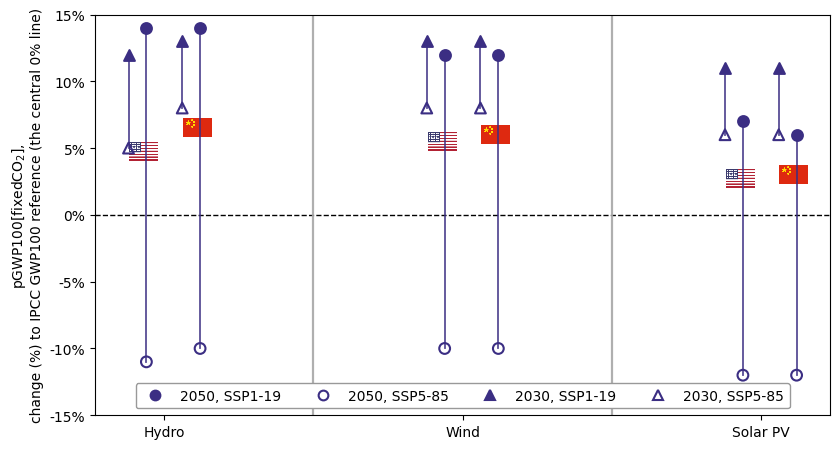

In [42]:
# Plot  
fig, ax = plot_fixedCO2_dumbbell_2030_2050_oneflag(df203050, figsize=(8.5,4.6))
plt.show()

In [43]:
fig.savefig("pGWP_fixedCO2_dumbbell_compt2IPCC_2030_2050.png", dpi=600, bbox_inches="tight")
#fig.savefig("pGWP_fixedCO2_dumbbell_compt2IPCC_2030_2050.pdf", bbox_inches="tight")